In [61]:
from dotenv import load_dotenv
import os
import pprint as pp
from opensearchpy import OpenSearch
from opensearchpy import helpers

load_dotenv()

OPENSEARCH_USER = os.getenv("OPENSEARCH_USER")
OPENSEARCH_PASSWORD = os.getenv("OPENSEARCH_PASSWORD")
OPENSEARCH_HOST = os.getenv("OPENSEARCH_HOST")
OPENSEARCH_PORT = os.getenv("OPENSEARCH_PORT")

index_name = OPENSEARCH_USER + '_project'

In [62]:
index_name = OPENSEARCH_USER + '_project'
# Create the client with SSL/TLS enabled, but hostname verification disabled.
client = OpenSearch(
    hosts = [{'host': OPENSEARCH_HOST, 'port': OPENSEARCH_PORT}],
    http_compress = True, # enables gzip compression for request bodies
    http_auth = (OPENSEARCH_USER, OPENSEARCH_PASSWORD),
    use_ssl = True,
    url_prefix = 'opensearch_v3',
    verify_certs = False,
    ssl_assert_hostname = False,
    ssl_show_warn = False
)


if client.indices.exists(index=index_name):

    resp = client.indices.open(index=index_name)
    print(resp)

    print("--- INDEX SETTINGS")
    settings = client.indices.get_settings(index=index_name)
    pp.pprint(settings)

    print("--- INDEX MAPPINGS")
    mappings = client.indices.get_mapping(index=index_name)
    pp.pprint(mappings)

    print("--- INDEX #DOCs")
    print(client.count(index=index_name))
else:
    print("Index does not exist.")


{'acknowledged': True, 'shards_acknowledged': True}
--- INDEX SETTINGS
{'uservl07_project': {'settings': {'index': {'creation_date': '1774973269602',
                                             'knn': 'true',
                                             'knn.derived_source': {'enabled': 'true'},
                                             'number_of_replicas': '0',
                                             'number_of_shards': '4',
                                             'provided_name': 'uservl07_project',
                                             'refresh_interval': '1s',
                                             'replication': {'type': 'DOCUMENT'},
                                             'similarity': {'bm25-0-75': {'b': '0.75',
                                                                          'k1': '0.0',
                                                                          'type': 'BM25'},
                                                            

In [63]:
from openai import OpenAI

BASE_URL = os.getenv("BASE_URL")
API_KEY = os.getenv("API_KEY")
MODEL = os.getenv("MODEL")

#print(repr(BASE_URL), repr(API_KEY), repr(MODEL))
openai_client = OpenAI(base_url=BASE_URL, api_key=API_KEY)
#NOTE: the model parameter is case sensitive, and must be exactly "google/gemma-4-31B-it" for the API to find it

response = openai_client.chat.completions.create(
    model=MODEL,
    messages=[
        {"role": "system", "content": "You are a helpful assistant."},
        {"role": "user", "content": "What is the capital of Portugal?"}
    ]
)
print(response.choices[0].message.content)

The capital of Portugal is **Lisbon**.


In [64]:
import base64
from IPython.display import Image, display

#openai_client = OpenAI(base_url=BASE_URL, api_key=API_KEY)
image_url = "lisbon.jpg"
with open(image_url, "rb") as f:
    image_b64 = base64.b64encode(f.read()).decode()
display(Image(url=image_url, width=400))
response = openai_client.chat.completions.create(
    model=MODEL,
    messages=[
            {"role": "system", "content": "You are a helpful visual assistant."},
            {"role": "user", "content": [
                {"type": "image_url", "image_url":
                    {"url": f"data:image/jpeg;base64,{image_b64}"}},
                {"type": "text", "text": "What is happening in this image?"}
            ]}
        ]
)
print(response.choices[0].message.content)

This is a scenic wide-angle shot of a coastal city, featuring a dense arrangement of historic buildings with traditional red-tiled roofs. 

Key elements of the image include:
* **Architecture:** The city is built on a slope leading down to the water. There are several prominent landmarks, including a large, white palatial complex on the upper left and a large domed cathedral or church on the right.
* **Waterfront:** In the foreground is a large body of blue water. A single white sailboat is gliding across the water, and there are piers and port structures along the shoreline.
* **Atmosphere:** The lighting suggests a bright, sunny day with a clear blue sky, highlighting the white and pastel colors of the urban landscape.

The image depicts a typical view of Lisbon, Portugal, looking across the Tagus River toward the city skyline.


In [65]:
from sentence_transformers import SentenceTransformer
from datasets import load_dataset
import aiohttp



sbert_model = SentenceTransformer('all-mpnet-base-v2')
bge_model = SentenceTransformer('BAAI/bge-small-en-v1.5')
ds = load_dataset("HuggingFaceM4/COCO", split="validation",
                  trust_remote_code=True,
                  storage_options={"client_kwargs": {"timeout": aiohttp.ClientTimeout(total=36000)}}
                  )

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-small-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [68]:
import io
##NOTE: review when index is back online, to check that the field names in the query match those in the index mapping
def retrieve_from_query(text_query, index_name=index_name, modality='BM25', top_k=3):
    if modality == 'BM25':
        query_body = {
            "size": top_k,
            "query": {
                "match": {
                    "caption": text_query
                }
            }
        }
    elif modality == 'SBERT':
        query_embedding = sbert_model.encode(text_query)
        query_body = {
            "size": top_k,
            "query": {
                "knn": {
                    "caption_vector": {
                        "vector": query_embedding,
                        "k": top_k
                    }
                }
            }
        }
    elif modality == 'BGE':
        query_embedding = bge_model.encode(text_query)
        query_body = {
            "size": top_k,
            "query": {
                "knn": {
                    "caption_vector_bge": {
                        "vector": query_embedding,
                        "k": top_k
                    }
                }
            }
        }
    else:
        raise ValueError(f"Unsupported modality: {modality}")
    
    response = client.search(index=index_name, body=query_body)
    return response['hits']['hits']

def generate_llm_answer(text_query, top_response, original_caption = False):
    #pass the top retrieved image and the original question to the LVLM via the vLLM endpoint to produce an answer.
    image_id = top_response['_source']['image_id'] #NOTE: check the field name when index is back online
    image = ds.filter(lambda x: x == int(image_id), input_columns=['imgid'])[0]['image'] #NOTE: check the field name when loading the dataset
    buffer = io.BytesIO()
    image.save(buffer, format="JPEG")
    image_b64 = base64.b64encode(buffer.getvalue()).decode()
    response = openai_client.chat.completions.create(
        model=MODEL,
        messages=[
            {"role": "system", "content": "You are a helpful visual assistant."},
            {"role": "user", "content": [
                {"type": "image_url", "image_url":
                    {"url": f"data:image/jpeg;base64,{image_b64}"}},
                {"type": "text", "text": text_query if not original_caption else f"{text_query} The original caption for this image is: {top_response['_source']['caption']}"}
            ]}
        ]
    )
    return response.choices[0].message.content

Top retrieved image id (BM25): 40238
Dataset column names: ['image', 'filepath', 'sentids', 'filename', 'imgid', 'split', 'sentences', 'cocoid']
[2, 2, 2, 2, 2, 15, 15, 15, 15, 15, 36, 36, 36, 36, 36, 53, 53, 53, 53, 53, 57, 57, 57, 57, 57, 60, 60, 60, 60, 60, 65, 65, 65, 65, 65, 73, 73, 73, 73, 73, 74, 74, 74, 74, 74, 82, 82, 82, 82, 82, 85, 85, 85, 85, 85, 88, 88, 88, 88, 88, 93, 93, 93, 93, 93, 105, 105, 105, 105, 105, 118, 118, 118, 118, 118, 127, 127, 127, 127, 127, 147, 147, 147, 147, 147, 150, 150, 150, 150, 150, 153, 153, 153, 153, 153, 154, 154, 154, 154, 154, 157, 157, 157, 157, 157, 168, 168, 168, 168, 168, 173, 173, 173, 173, 173, 180, 180, 180, 180, 180, 181, 181, 181, 181, 181, 195, 195, 195, 195, 195, 203, 203, 203, 203, 203, 207, 207, 207, 207, 207, 212, 212, 212, 212, 212, 222, 222, 222, 222, 222, 225, 225, 225, 225, 225, 227, 227, 227, 227, 227, 231, 231, 231, 231, 231, 239, 239, 239, 239, 239, 247, 247, 247, 247, 247, 268, 268, 268, 268, 268, 272, 272, 272, 272, 272,

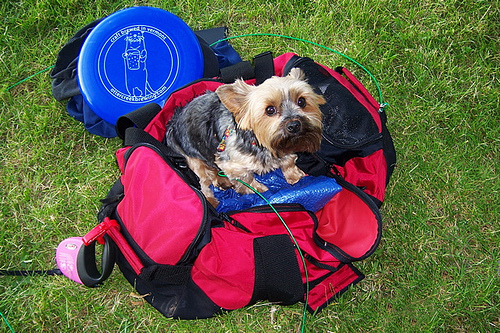

LLM answer (BM25): In this image, a small, terrier-mix dog is sitting inside a red and black sports bag that is resting on a grassy lawn. The dog is looking directly at the camera. Next to the bag is a bright blue flying disc (Frisbee).


In [69]:
text_query = "What is happening in this image?"

retrieve_image_bm= retrieve_from_query(text_query, modality='BM25')

print("Top retrieved image id (BM25):", retrieve_image_bm[0]['_source']['image_id'])
#_id field corresponds to ds sentid, image_id corresponds to the ds imgid coloumn
retrieved_img_id = retrieve_image_bm[0]['_source']['image_id']
print("Dataset column names:", ds.column_names)
print(ds['imgid'])
print("Retrieved image ID:", retrieved_img_id)

img = ds.filter(lambda x: x == int(retrieved_img_id), input_columns=['imgid'])[0]['image']
display(img)

answer_bm = generate_llm_answer(text_query, retrieve_image_bm[0])
print("LLM answer (BM25):", answer_bm)
